In [ ]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [ ]:
import shap
print(shap.__version__)

In [8]:
import os
import sys
import pandas as pd
import numpy as np

# Add the project root to Python's path
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd

customer_df = pd.read_csv(
    "data/processed/customer_churn_features.csv"
)

print(customer_df.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/customer_churn_features.csv'

In [9]:
import os
import sys

# Add the project root to Python's path
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd

customer_df = pd.read_csv("../data/processed/customer_features.csv")
    
print(customer_df.shape)

customer_df.head()

(5942, 12)


,Customer ID,TotalSpend,TotalOrders,TotalProducts,AverageOrderValue,FirstPurchase,LastPurchase,CustomerTenure,TenureMonths,PurchaseFrequencyPerMonth,AverageSpendPerProduct,AverageQuantityPerOrder
0,12346.0,-64.68,17,52,-1.347500,2009-12-14 08:34:00,2011-01-18 10:17:00,400,13.333333,1.275000,-1.243846,3.058824
1,12347.0,5633.32,8,3286,22.266087,2010-10-31 14:20:00,2011-12-07 15:52:00,402,13.400000,0.597015,1.714340,410.750000
2,12348.0,2019.40,5,2714,39.596078,2010-09-27 14:59:00,2011-09-25 13:13:00,362,12.066667,0.414365,0.744068,542.800000
3,12349.0,4404.54,5,1619,24.469667,2009-12-04 12:49:00,2011-11-21 09:51:00,716,23.866667,0.209497,2.720531,323.800000
4,12350.0,334.40,1,197,19.670588,2011-02-02 16:01:00,2011-02-02 16:01:00,0,1.000000,1.000000,1.697462,197.000000


In [10]:
import pandas as pd

customer_df["LastPurchase"] = pd.to_datetime(customer_df["LastPurchase"])
customer_df["FirstPurchase"] = pd.to_datetime(customer_df["FirstPurchase"])

In [5]:
# Find the latest purchase date
snapshot_date = customer_df["LastPurchase"].max()

print("Last transaction date:", snapshot_date)

# Calculate Recency
customer_df["Recency"] = (
    snapshot_date - customer_df["LastPurchase"]
).dt.days

# Create Churn column
customer_df["Churn"] = (
    customer_df["Recency"] > 90
).astype(int)

customer_df.head()

Last transaction date: 2011-12-09 12:50:00


,Customer ID,TotalSpend,TotalOrders,TotalProducts,AverageOrderValue,FirstPurchase,LastPurchase,CustomerTenure,TenureMonths,PurchaseFrequencyPerMonth,AverageSpendPerProduct,AverageQuantityPerOrder,Recency,Churn
0,12346.0,-64.68,17,52,-1.347500,2009-12-14 08:34:00,2011-01-18 10:17:00,400,13.333333,1.275000,-1.243846,3.058824,325,1
1,12347.0,5633.32,8,3286,22.266087,2010-10-31 14:20:00,2011-12-07 15:52:00,402,13.400000,0.597015,1.714340,410.750000,1,0
2,12348.0,2019.40,5,2714,39.596078,2010-09-27 14:59:00,2011-09-25 13:13:00,362,12.066667,0.414365,0.744068,542.800000,74,0
3,12349.0,4404.54,5,1619,24.469667,2009-12-04 12:49:00,2011-11-21 09:51:00,716,23.866667,0.209497,2.720531,323.800000,18,0
4,12350.0,334.40,1,197,19.670588,2011-02-02 16:01:00,2011-02-02 16:01:00,0,1.000000,1.000000,1.697462,197.000000,309,1


In [12]:
print(customer_df["LastPurchase"].dtype)
print(customer_df["LastPurchase"].head())

datetime64[us]
0   2011-01-18 10:17:00
1   2011-12-07 15:52:00
2   2011-09-25 13:13:00
3   2011-11-21 09:51:00
4   2011-02-02 16:01:00
Name: LastPurchase, dtype: datetime64[us]


In [6]:
customer_df.to_csv(
    "../data/processed/customer_churn_features.csv",
    index=False
)

print("Customer churn features saved successfully.")

Customer churn features saved successfully.


In [7]:
import os

print(os.path.exists("../data/processed/customer_churn_features.csv"))

True


In [13]:
import os

print(os.getcwd())

c:\Users\ADMIN\OneDrive\Documents\GitHub\Customer-behavior-prediction\notebooks


In [14]:
# customer_df already contains the Churn column
model_data = customer_df.copy()

print(model_data.shape)
model_data.head()

(5942, 14)


,Customer ID,TotalSpend,TotalOrders,TotalProducts,AverageOrderValue,FirstPurchase,LastPurchase,CustomerTenure,TenureMonths,PurchaseFrequencyPerMonth,AverageSpendPerProduct,AverageQuantityPerOrder,Recency,Churn
0,12346.0,-64.68,17,52,-1.347500,2009-12-14 08:34:00,2011-01-18 10:17:00,400,13.333333,1.275000,-1.243846,3.058824,325,1
1,12347.0,5633.32,8,3286,22.266087,2010-10-31 14:20:00,2011-12-07 15:52:00,402,13.400000,0.597015,1.714340,410.750000,1,0
2,12348.0,2019.40,5,2714,39.596078,2010-09-27 14:59:00,2011-09-25 13:13:00,362,12.066667,0.414365,0.744068,542.800000,74,0
3,12349.0,4404.54,5,1619,24.469667,2009-12-04 12:49:00,2011-11-21 09:51:00,716,23.866667,0.209497,2.720531,323.800000,18,0
4,12350.0,334.40,1,197,19.670588,2011-02-02 16:01:00,2011-02-02 16:01:00,0,1.000000,1.000000,1.697462,197.000000,309,1


In [15]:
customer_features = pd.read_csv("../data/processed/customer_features.csv")

print(customer_features.shape)
customer_features.head()

(5942, 12)


,Customer ID,TotalSpend,TotalOrders,TotalProducts,AverageOrderValue,FirstPurchase,LastPurchase,CustomerTenure,TenureMonths,PurchaseFrequencyPerMonth,AverageSpendPerProduct,AverageQuantityPerOrder
0,12346.0,-64.68,17,52,-1.347500,2009-12-14 08:34:00,2011-01-18 10:17:00,400,13.333333,1.275000,-1.243846,3.058824
1,12347.0,5633.32,8,3286,22.266087,2010-10-31 14:20:00,2011-12-07 15:52:00,402,13.400000,0.597015,1.714340,410.750000
2,12348.0,2019.40,5,2714,39.596078,2010-09-27 14:59:00,2011-09-25 13:13:00,362,12.066667,0.414365,0.744068,542.800000
3,12349.0,4404.54,5,1619,24.469667,2009-12-04 12:49:00,2011-11-21 09:51:00,716,23.866667,0.209497,2.720531,323.800000
4,12350.0,334.40,1,197,19.670588,2011-02-02 16:01:00,2011-02-02 16:01:00,0,1.000000,1.000000,1.697462,197.000000


In [16]:
# Use the prepared customer dataset with Churn already included
model_data = customer_df.copy()

print(model_data.shape)
model_data.head()

(5942, 14)


,Customer ID,TotalSpend,TotalOrders,TotalProducts,AverageOrderValue,FirstPurchase,LastPurchase,CustomerTenure,TenureMonths,PurchaseFrequencyPerMonth,AverageSpendPerProduct,AverageQuantityPerOrder,Recency,Churn
0,12346.0,-64.68,17,52,-1.347500,2009-12-14 08:34:00,2011-01-18 10:17:00,400,13.333333,1.275000,-1.243846,3.058824,325,1
1,12347.0,5633.32,8,3286,22.266087,2010-10-31 14:20:00,2011-12-07 15:52:00,402,13.400000,0.597015,1.714340,410.750000,1,0
2,12348.0,2019.40,5,2714,39.596078,2010-09-27 14:59:00,2011-09-25 13:13:00,362,12.066667,0.414365,0.744068,542.800000,74,0
3,12349.0,4404.54,5,1619,24.469667,2009-12-04 12:49:00,2011-11-21 09:51:00,716,23.866667,0.209497,2.720531,323.800000,18,0
4,12350.0,334.40,1,197,19.670588,2011-02-02 16:01:00,2011-02-02 16:01:00,0,1.000000,1.000000,1.697462,197.000000,309,1


In [17]:
import numpy as np

# Remove date columns
model_data = model_data.drop(columns=["FirstPurchase", "LastPurchase"])

# Replace Infinity with NaN
model_data = model_data.replace([np.inf, -np.inf], np.nan)

# Fill missing values
model_data = model_data.fillna(0)

print(model_data.isna().sum())

Customer ID                  0
TotalSpend                   0
TotalOrders                  0
TotalProducts                0
AverageOrderValue            0
CustomerTenure               0
TenureMonths                 0
PurchaseFrequencyPerMonth    0
AverageSpendPerProduct       0
AverageQuantityPerOrder      0
Recency                      0
Churn                        0
dtype: int64


In [18]:
from sklearn.model_selection import train_test_split

# Features (X) - keep only numeric columns
X = model_data.select_dtypes(include=["number"]).drop(
    columns=["Customer ID", "Churn"]
)

# Target (y)
y = model_data["Churn"]

print(X.columns)
print(X.shape)    

Index(['TotalSpend', 'TotalOrders', 'TotalProducts', 'AverageOrderValue',
       'CustomerTenure', 'TenureMonths', 'PurchaseFrequencyPerMonth',
       'AverageSpendPerProduct', 'AverageQuantityPerOrder', 'Recency'],
      dtype='str')
(5942, 10)


In [19]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (4753, 10)
Testing set : (1189, 10)


In [20]:
print("Columns in model_data:")
print(model_data.columns)

print("\nColumns in X:")
print(X.columns)

Columns in model_data:
Index(['Customer ID', 'TotalSpend', 'TotalOrders', 'TotalProducts',
       'AverageOrderValue', 'CustomerTenure', 'TenureMonths',
       'PurchaseFrequencyPerMonth', 'AverageSpendPerProduct',
       'AverageQuantityPerOrder', 'Recency', 'Churn'],
      dtype='str')

Columns in X:
Index(['TotalSpend', 'TotalOrders', 'TotalProducts', 'AverageOrderValue',
       'CustomerTenure', 'TenureMonths', 'PurchaseFrequencyPerMonth',
       'AverageSpendPerProduct', 'AverageQuantityPerOrder', 'Recency'],
      dtype='str')


In [21]:
import numpy as np

# Check for infinity values
print("Infinity values in each column:")
print(np.isinf(X_train).sum())

print("\nColumns containing infinity:")
print(X_train.columns[np.isinf(X_train).any()])

Infinity values in each column:
TotalSpend                   0
TotalOrders                  0
TotalProducts                0
AverageOrderValue            0
CustomerTenure               0
TenureMonths                 0
PurchaseFrequencyPerMonth    0
AverageSpendPerProduct       0
AverageQuantityPerOrder      0
Recency                      0
dtype: int64

Columns containing infinity:
Index([], dtype='str')


In [22]:
import numpy as np

# Replace infinity values with NaN
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN values with the median of the training data
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

print("Infinity values remaining:", np.isinf(X_train).sum().sum())
print("Missing values remaining:", X_train.isna().sum().sum())

Infinity values remaining: 0
Missing values remaining: 0


In [23]:
from sklearn.preprocessing import StandardScaler

numeric_features = [
    "TotalSpend",
    "TotalOrders",
    "TotalProducts",
    "AverageOrderValue",
    "CustomerTenure",
    "TenureMonths",
    "PurchaseFrequencyPerMonth",
    "AverageSpendPerProduct",
    "AverageQuantityPerOrder"
]

scaler = StandardScaler()

X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

print("Feature scaling completed successfully!")

Feature scaling completed successfully!

In [24]:
# Check class balance
print(model_data["Churn"].value_counts())

print("\nPercentage:")

print(model_data["Churn"].value_counts(normalize=True) * 100)

Churn
1    3020
0    2922
Name: count, dtype: int64

Percentage:
Churn
1    50.824638
0    49.175362
Name: proportion, dtype: float64


In [25]:
print(model_data.columns)

Index(['Customer ID', 'TotalSpend', 'TotalOrders', 'TotalProducts',
       'AverageOrderValue', 'CustomerTenure', 'TenureMonths',
       'PurchaseFrequencyPerMonth', 'AverageSpendPerProduct',
       'AverageQuantityPerOrder', 'Recency', 'Churn'],
      dtype='str')


In [26]:
print(model_data.shape)

(5942, 12)


In [27]:
from sklearn.model_selection import train_test_split

# Features (X)
X = model_data.drop(columns=[
    "Customer ID",
    "Churn",
    "Recency"
])

# Target (y)
y = model_data["Churn"]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (4753, 9)
Testing set : (1189, 9)


In [28]:
from xgboost import XGBClassifier

# Create XGBoost model
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Train the model
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Predictions
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.7098402018502944
Precision: 0.6983154670750383
Recall   : 0.7549668874172185
F1 Score : 0.7255369928400954
ROC-AUC  : 0.7854898964170488

Confusion Matrix
[[388 197]
 [148 456]]

Classification Report
              precision    recall  f1-score   support

           0       0.72      0.66      0.69       585
           1       0.70      0.75      0.73       604

    accuracy                           0.71      1189
   macro avg       0.71      0.71      0.71      1189
weighted avg       0.71      0.71      0.71      1189



In [30]:
import pandas as pd

# Model comparison table
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "SVM",
        "KNN",
        "Gradient Boosting"
    ],
    "Accuracy": [
        0.7157,
        0.6552,
        0.7174,
        0.7098,
        0.7065,
        0.7174,
        0.7435
    ],
    "Precision": [
        0.6985,
        0.6617,
        0.7030,
        0.6983,
        0.6684,
        0.7120,
        0.7170
    ],
    "Recall": [
        0.7748,
        0.6573,
        0.7682,
        0.7550,
        0.8377,
        0.7450,
        0.8179
    ],
    "F1 Score": [
        0.7347,
        0.6595,
        0.7342,
        0.7255,
        0.7436,
        0.7282,
        0.7641
    ],
    "ROC-AUC": [
        0.7788,
        0.6551,
        0.7885,
        0.7855,
        0.7043,
        0.7170,
        0.7423
    ]
})

comparison = comparison.sort_values(by="ROC-AUC", ascending=False)

display(comparison)

comparison.to_csv("../data/processed/model_comparison.csv", index=False)

print("✅ Updated model comparison saved successfully!")

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.7174,0.7030,0.7682,0.7342,0.7885
3,XGBoost,0.7098,0.6983,0.7550,0.7255,0.7855
0,Logistic Regression,0.7157,0.6985,0.7748,0.7347,0.7788
6,Gradient Boosting,0.7435,0.7170,0.8179,0.7641,0.7423
5,KNN,0.7174,0.7120,0.7450,0.7282,0.7170
4,SVM,0.7065,0.6684,0.8377,0.7436,0.7043
1,Decision Tree,0.6552,0.6617,0.6573,0.6595,0.6551


✅ Updated model comparison saved successfully!


In [31]:
from sklearn.linear_model import LogisticRegression

# Create the model
log_model = LogisticRegression(max_iter=2000)

# Train the model
log_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Predictions
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.7157275021026073
Precision: 0.6985074626865672
Recall   : 0.7748344370860927
F1 Score : 0.7346938775510204
ROC-AUC  : 0.7787909662081848

Confusion Matrix
[[383 202]
 [136 468]]

Classification Report
              precision    recall  f1-score   support

           0       0.74      0.65      0.69       585
           1       0.70      0.77      0.73       604

    accuracy                           0.72      1189
   macro avg       0.72      0.71      0.71      1189
weighted avg       0.72      0.72      0.71      1189



In [33]:
from sklearn.tree import DecisionTreeClassifier

In [34]:
# Create the model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [35]:
# Make predictions
y_pred_dt = dt_model.predict(X_test)

# Predict probabilities (needed for ROC-AUC)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_dt))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

Accuracy : 0.6551724137931034
Precision: 0.6616666666666666
Recall   : 0.6572847682119205
F1 Score : 0.659468438538206
ROC-AUC  : 0.6551381106016867

Confusion Matrix
[[382 203]
 [207 397]]

Classification Report
              precision    recall  f1-score   support

           0       0.65      0.65      0.65       585
           1       0.66      0.66      0.66       604

    accuracy                           0.66      1189
   macro avg       0.66      0.66      0.66      1189
weighted avg       0.66      0.66      0.66      1189



In [36]:
from sklearn.ensemble import RandomForestClassifier

In [37]:
# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [38]:
# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Predict probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.7174095878889823
Precision: 0.703030303030303
Recall   : 0.7682119205298014
F1 Score : 0.7341772151898734
ROC-AUC  : 0.7884926699496236

Confusion Matrix
[[389 196]
 [140 464]]

Classification Report
              precision    recall  f1-score   support

           0       0.74      0.66      0.70       585
           1       0.70      0.77      0.73       604

    accuracy                           0.72      1189
   macro avg       0.72      0.72      0.72      1189
weighted avg       0.72      0.72      0.72      1189



In [40]:
import pandas as pd

comparison = pd.DataFrame({

    "Model": [
        "Random Forest",
        "XGBoost",
        "Logistic Regression",
        "Gradient Boosting",
        "KNN",
        "SVM",
        "Decision Tree"
    ],

    "Accuracy": [
        0.7174,
        0.7098,
        0.7157,
        0.7435,
        0.7174,
        0.7065,
        0.6552
    ],

    "Precision": [
        0.7030,
        0.6983,
        0.6985,
        0.7170,
        0.7120,
        0.6684,
        0.6617
    ],

    "Recall": [
        0.7682,
        0.7550,
        0.7748,
        0.8179,
        0.7450,
        0.8377,
        0.6573
    ],

    "F1 Score": [
        0.7342,
        0.7255,
        0.7347,
        0.7641,
        0.7282,
        0.7436,
        0.6595
    ],

    "ROC-AUC": [
        0.7885,
        0.7855,
        0.7788,
        0.7423,
        0.7170,
        0.7043,
        0.6551
    ]
})

display(comparison)

comparison.to_csv(
    "../data/processed/model_comparison.csv",
    index=False
)

print("✅ Updated model comparison saved successfully!")

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.7174,0.7030,0.7682,0.7342,0.7885
1,XGBoost,0.7098,0.6983,0.7550,0.7255,0.7855
2,Logistic Regression,0.7157,0.6985,0.7748,0.7347,0.7788
3,Gradient Boosting,0.7435,0.7170,0.8179,0.7641,0.7423
4,KNN,0.7174,0.7120,0.7450,0.7282,0.7170
5,SVM,0.7065,0.6684,0.8377,0.7436,0.7043
6,Decision Tree,0.6552,0.6617,0.6573,0.6595,0.6551


✅ Updated model comparison saved successfully!


In [41]:
comparison.to_csv(
    "../data/processed/model_comparison.csv",
    index=False
)

print("Model comparison table saved successfully!")

Model comparison table saved successfully!


In [45]:
print(comparison)

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0        Random Forest    0.7174     0.7030  0.7682    0.7342   0.7885
1              XGBoost    0.7098     0.6983  0.7550    0.7255   0.7855
2  Logistic Regression    0.7157     0.6985  0.7748    0.7347   0.7788
3    Gradient Boosting    0.7435     0.7170  0.8179    0.7641   0.7423
4                  KNN    0.7174     0.7120  0.7450    0.7282   0.7170
5                  SVM    0.7065     0.6684  0.8377    0.7436   0.7043
6        Decision Tree    0.6552     0.6617  0.6573    0.6595   0.6551


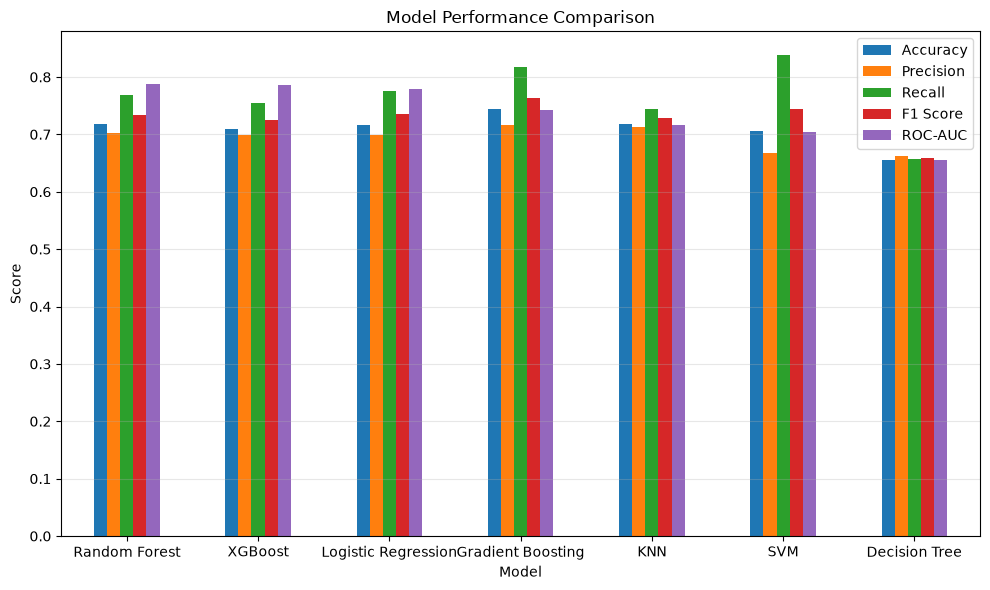

In [46]:
import matplotlib.pyplot as plt

comparison.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

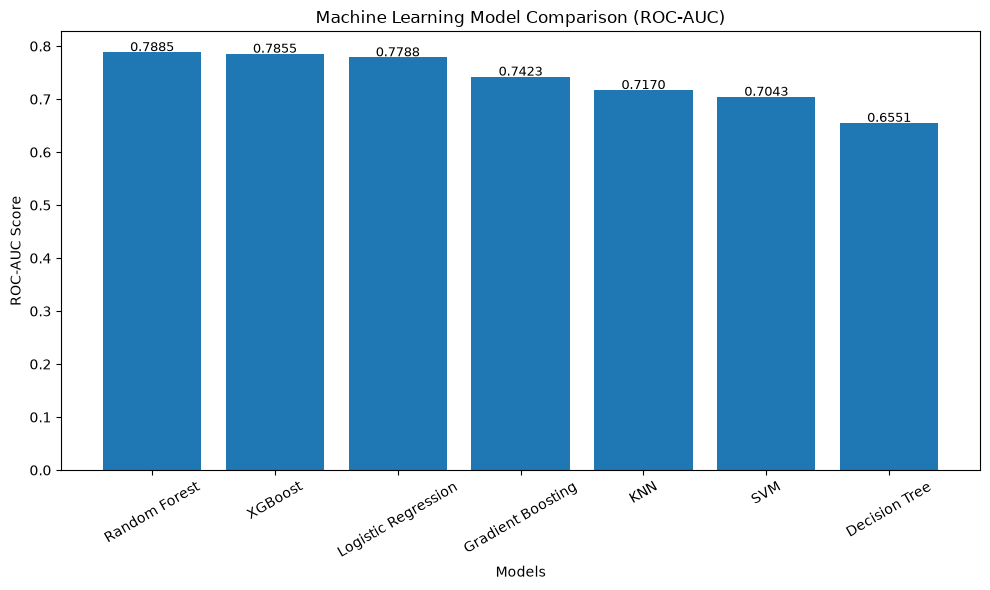

In [ ]:
import os
import matplotlib.pyplot as plt

# Sort models by ROC-AUC
comparison_sorted = comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

plt.figure(figsize=(10,6))

bars = plt.bar(
    comparison_sorted["Model"],
    comparison_sorted["ROC-AUC"]
)

plt.title("Machine Learning Model Comparison (ROC-AUC)")
plt.xlabel("Models")
plt.ylabel("ROC-AUC Score")

plt.xticks(rotation=30)

# Display ROC-AUC values on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f"{height:.4f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

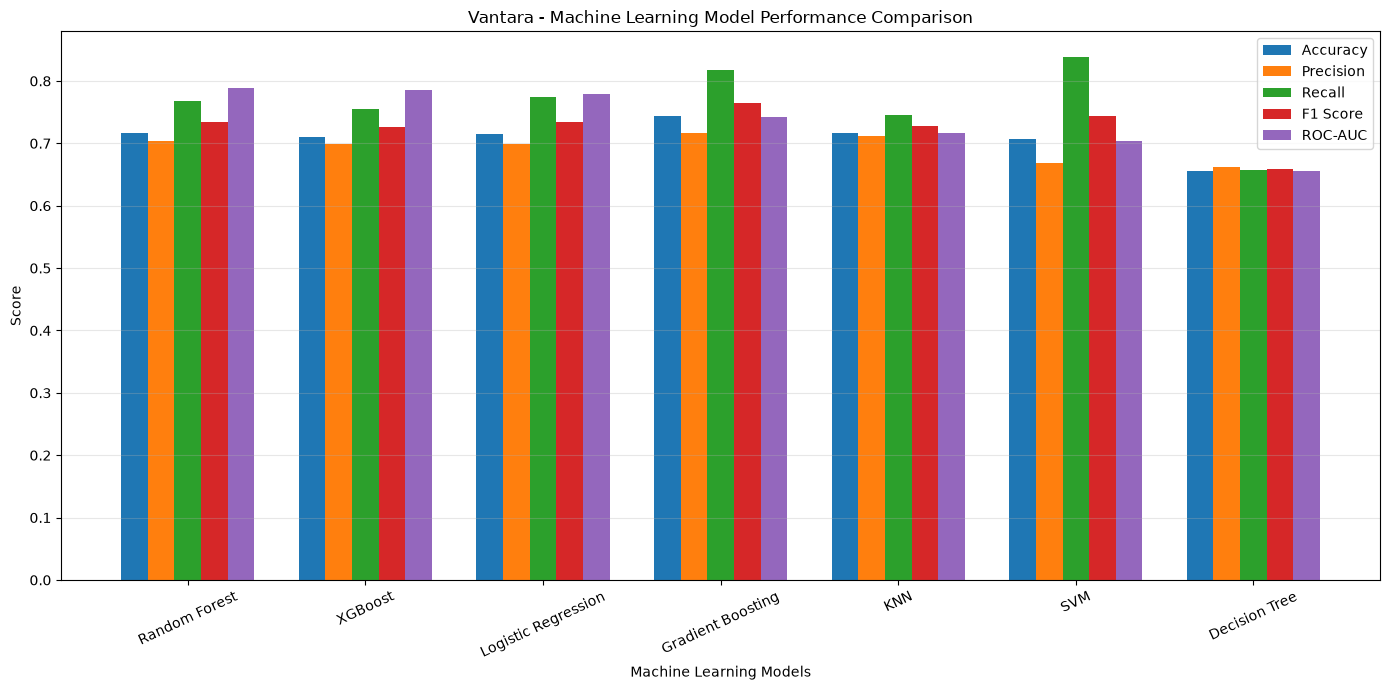

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

x = np.arange(len(comparison))
width = 0.15

plt.figure(figsize=(14,7))

for i, metric in enumerate(metrics):
    plt.bar(
        x + i*width,
        comparison[metric],
        width,
        label=metric
    )

plt.xticks(
    x + width*2,
    comparison["Model"],
    rotation=25
)

plt.ylabel("Score")
plt.xlabel("Machine Learning Models")
plt.title("Vantara - Machine Learning Model Performance Comparison")

plt.legend()

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

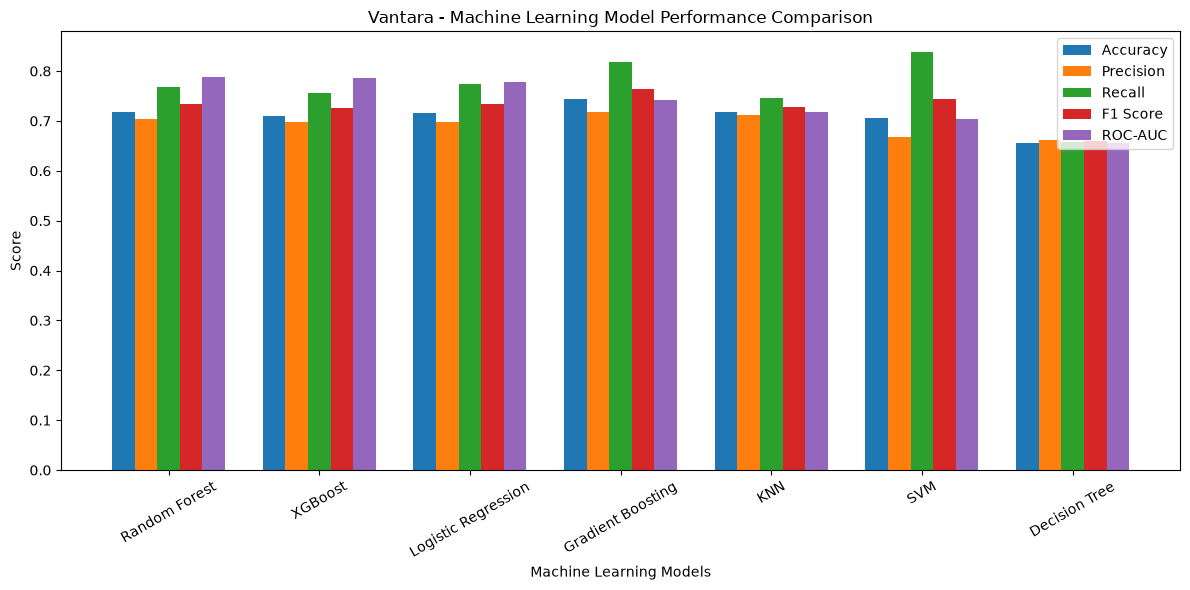

✅ All metrics comparison graph saved successfully!


In [ ]:
import os
import matplotlib.pyplot as plt

# Create reports folder if not present
os.makedirs("../reports", exist_ok=True)

# Plot all metrics
plt.figure(figsize=(12,6))

comparison_plot = comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

x = range(len(comparison_plot))

plt.bar(
    [i-0.3 for i in x],
    comparison_plot["Accuracy"],
    width=0.15,
    label="Accuracy"
)

plt.bar(
    [i-0.15 for i in x],
    comparison_plot["Precision"],
    width=0.15,
    label="Precision"
)

plt.bar(
    x,
    comparison_plot["Recall"],
    width=0.15,
    label="Recall"
)

plt.bar(
    [i+0.15 for i in x],
    comparison_plot["F1 Score"],
    width=0.15,
    label="F1 Score"
)

plt.bar(
    [i+0.3 for i in x],
    comparison_plot["ROC-AUC"],
    width=0.15,
    label="ROC-AUC"
)

plt.xticks(
    x,
    comparison_plot["Model"],
    rotation=30
)

plt.xlabel("Machine Learning Models")
plt.ylabel("Score")
plt.title("Vantara - Machine Learning Model Performance Comparison")

plt.legend()
plt.tight_layout()

# Save colourful graph
plt.savefig(
    "../reports/model_performance_comparison_all_metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ All metrics comparison graph saved successfully!")

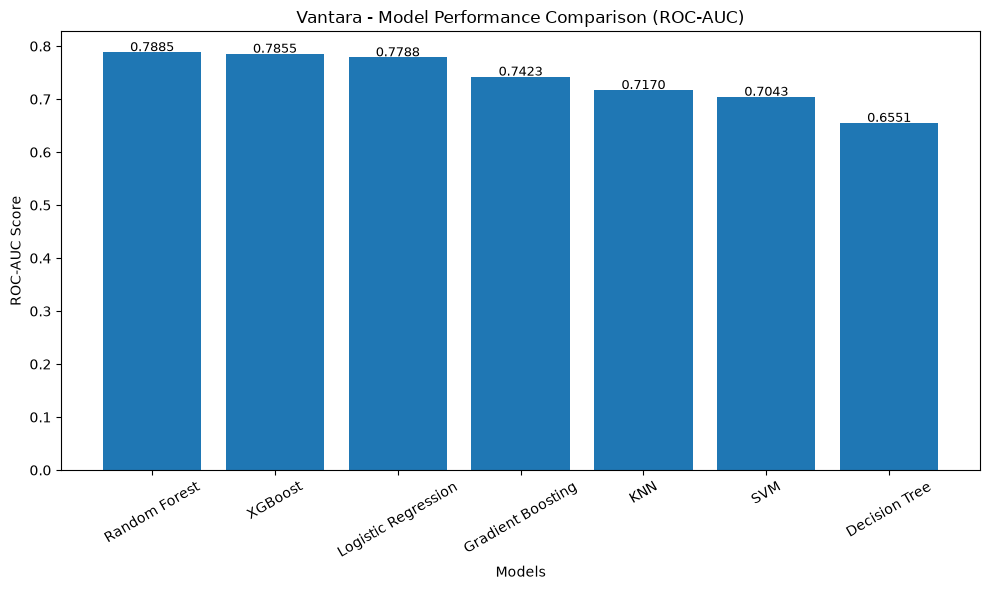

✅ ROC-AUC comparison graph saved successfully!


In [ ]:
import os
import matplotlib.pyplot as plt

# Create reports folder if it doesn't exist
os.makedirs("../reports", exist_ok=True)

# Sort by ROC-AUC
comparison_sorted = comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

plt.figure(figsize=(10,6))

bars = plt.bar(
    comparison_sorted["Model"],
    comparison_sorted["ROC-AUC"]
)

plt.title("Vantara - Model Performance Comparison (ROC-AUC)")
plt.xlabel("Models")
plt.ylabel("ROC-AUC Score")

plt.xticks(rotation=30)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f"{height:.4f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

# Save graph
plt.savefig(
    "../reports/model_comparison_roc_auc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ ROC-AUC comparison graph saved successfully!")

In [ ]:
# Check missing values in model_data
print(model_data.isnull().sum())

Customer ID                  0
TotalSpend                   0
TotalOrders                  0
TotalProducts                0
AverageOrderValue            0
CustomerTenure               0
TenureMonths                 0
PurchaseFrequencyPerMonth    0
AverageSpendPerProduct       0
AverageQuantityPerOrder      0
Recency                      0
Churn                        0
dtype: int64


In [ ]:
# Replace missing values with 0
model_data["AverageSpendPerProduct"] = (
    model_data["AverageSpendPerProduct"]
    .fillna(0)
)

# Verify
print(model_data.isnull().sum())

Customer ID                  0
TotalSpend                   0
TotalOrders                  0
TotalProducts                0
AverageOrderValue            0
CustomerTenure               0
TenureMonths                 0
PurchaseFrequencyPerMonth    0
AverageSpendPerProduct       0
AverageQuantityPerOrder      0
Recency                      0
Churn                        0
dtype: int64


In [ ]:
print(X_train.isnull().sum())

TotalSpend                   0
TotalOrders                  0
TotalProducts                0
AverageOrderValue            0
CustomerTenure               0
TenureMonths                 0
PurchaseFrequencyPerMonth    0
AverageSpendPerProduct       0
AverageQuantityPerOrder      0
dtype: int64


In [ ]:
print(X_train.isnull().sum().sum())

0


In [ ]:
import numpy as np

print(np.isinf(X_train).sum())
print(np.isinf(X_train).sum().sum())

TotalSpend                   0
TotalOrders                  0
TotalProducts                0
AverageOrderValue            0
CustomerTenure               0
TenureMonths                 0
PurchaseFrequencyPerMonth    0
AverageSpendPerProduct       0
AverageQuantityPerOrder      0
dtype: int64
0


In [ ]:
print(X_train.shape)
print(X_train.isnull().sum().sum())

(4753, 9)
0


In [ ]:
import numpy as np

# Check infinity values in every column
print(np.isinf(X_train).sum())

# Total number of infinity values
print(np.isinf(X_train).sum().sum())

TotalSpend                   0
TotalOrders                  0
TotalProducts                0
AverageOrderValue            0
CustomerTenure               0
TenureMonths                 0
PurchaseFrequencyPerMonth    0
AverageSpendPerProduct       0
AverageQuantityPerOrder      0
dtype: int64
0


In [ ]:
# Replace infinity values with 0
X_train = X_train.replace([np.inf, -np.inf], 0)
X_test = X_test.replace([np.inf, -np.inf], 0)

# Verify
print(np.isinf(X_train).sum())
print(np.isinf(X_train).sum().sum())

TotalSpend                   0
TotalOrders                  0
TotalProducts                0
AverageOrderValue            0
CustomerTenure               0
TenureMonths                 0
PurchaseFrequencyPerMonth    0
AverageSpendPerProduct       0
AverageQuantityPerOrder      0
dtype: int64
0


In [ ]:
model_data[model_data["AverageSpendPerProduct"].isna()]

,Customer ID,TotalSpend,TotalOrders,TotalProducts,AverageOrderValue,CustomerTenure,TenureMonths,PurchaseFrequencyPerMonth,AverageSpendPerProduct,AverageQuantityPerOrder,Recency,Churn


In [ ]:
import numpy as np

model_data["AverageSpendPerProduct"] = (
    model_data["AverageSpendPerProduct"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

print(model_data["AverageSpendPerProduct"].isnull().sum())
print(np.isinf(model_data["AverageSpendPerProduct"]).sum())

0
0


In [ ]:
print(X_train.dtypes)

TotalSpend                   float64
TotalOrders                    int64
TotalProducts                  int64
AverageOrderValue            float64
CustomerTenure                 int64
TenureMonths                 float64
PurchaseFrequencyPerMonth    float64
AverageSpendPerProduct       float64
AverageQuantityPerOrder      float64
dtype: object


In [ ]:
try:
    import xgboost
    print("XGBoost is already installed!")
except ImportError:
    print("XGBoost is NOT installed.")

XGBoost is already installed!


In [ ]:
from xgboost import XGBClassifier

# Create XGBoost model
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Train the model
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [ ]:
print(customer_df.head())


   Customer ID  TotalSpend  TotalOrders  TotalProducts  AverageOrderValue  \
0      12346.0      -64.68           17             52          -1.347500   
1      12347.0     5633.32            8           3286          22.266087   
2      12348.0     2019.40            5           2714          39.596078   
3      12349.0     4404.54            5           1619          24.469667   
4      12350.0      334.40            1            197          19.670588   

        FirstPurchase        LastPurchase  CustomerTenure  TenureMonths  \
0 2009-12-14 08:34:00 2011-01-18 10:17:00             400     13.333333   
1 2010-10-31 14:20:00 2011-12-07 15:52:00             402     13.400000   
2 2010-09-27 14:59:00 2011-09-25 13:13:00             362     12.066667   
3 2009-12-04 12:49:00 2011-11-21 09:51:00             716     23.866667   
4 2011-02-02 16:01:00 2011-02-02 16:01:00               0      1.000000   

   PurchaseFrequencyPerMonth  AverageSpendPerProduct  AverageQuantityPerOrder  \
0    

In [ ]:
print("Kernel is working")

Kernel is working


In [ ]:
import pandas as pd
print(pd.__version__)

3.0.3


In [ ]:
import os

print(os.getcwd())

c:\Users\ADMIN\OneDrive\Documents\GitHub\Customer-behavior-prediction\notebooks


In [ ]:
import os

print(os.path.abspath("../reports/model_performance_comparison.png"))

c:\Users\ADMIN\OneDrive\Documents\GitHub\Customer-behavior-prediction\reports\model_performance_comparison.png


In [ ]:
import os

print(os.path.abspath("../reports/model_performance_comparison.png"))
print(os.path.exists("../reports/model_performance_comparison.png"))

c:\Users\ADMIN\OneDrive\Documents\GitHub\Customer-behavior-prediction\reports\model_performance_comparison.png
True


In [ ]:
print(comparison.shape)
print(comparison.shape)

print("\ncomparison")
print(comparison)

print("\ncomparison")
print(comparison)

(4, 6)
(4, 6)

comparison
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.7157     0.6985  0.7748    0.7347   0.7788
1        Decision Tree    0.6552     0.6617  0.6573    0.6595   0.6551
2        Random Forest    0.7174     0.7030  0.7682    0.7342   0.7885
3              XGBoost    0.7098     0.6983  0.7550    0.7255   0.7855

comparison
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.7157     0.6985  0.7748    0.7347   0.7788
1        Decision Tree    0.6552     0.6617  0.6573    0.6595   0.6551
2        Random Forest    0.7174     0.7030  0.7682    0.7342   0.7885
3              XGBoost    0.7098     0.6983  0.7550    0.7255   0.7855


In [ ]:
print(X_train.select_dtypes(include=["datetime64[ns]"]).columns)

Index([], dtype='str')


In [ ]:
print(X_train.dtypes)

TotalSpend                   float64
TotalOrders                    int64
TotalProducts                  int64
AverageOrderValue            float64
CustomerTenure                 int64
TenureMonths                 float64
PurchaseFrequencyPerMonth    float64
AverageSpendPerProduct       float64
AverageQuantityPerOrder      float64
dtype: object


In [ ]:
print(X_train.select_dtypes(include=["object"]).columns)

Index([], dtype='str')


In [ ]:
print(X.columns)

Index(['TotalSpend', 'TotalOrders', 'TotalProducts', 'AverageOrderValue',
       'CustomerTenure', 'TenureMonths', 'PurchaseFrequencyPerMonth',
       'AverageSpendPerProduct', 'AverageQuantityPerOrder'],
      dtype='str')


In [ ]:
print(X.shape)

(5942, 9)


In [ ]:
print(X_train.columns)

Index(['TotalSpend', 'TotalOrders', 'TotalProducts', 'AverageOrderValue',
       'CustomerTenure', 'TenureMonths', 'PurchaseFrequencyPerMonth',
       'AverageSpendPerProduct', 'AverageQuantityPerOrder'],
      dtype='str')


In [ ]:
for col in model_data.columns:
    print(repr(col))

'Customer ID'
'TotalSpend'
'TotalOrders'
'TotalProducts'
'AverageOrderValue'
'CustomerTenure'
'TenureMonths'
'PurchaseFrequencyPerMonth'
'AverageSpendPerProduct'
'AverageQuantityPerOrder'
'Recency'
'Churn'


In [ ]:
print(customer_features.columns.tolist())


['Customer ID', 'TotalSpend', 'TotalOrders', 'TotalProducts', 'AverageOrderValue', 'FirstPurchase', 'LastPurchase', 'CustomerTenure', 'TenureMonths', 'PurchaseFrequencyPerMonth', 'AverageSpendPerProduct', 'AverageQuantityPerOrder']


In [4]:
customer_df["LastPurchase"] = pd.to_datetime(
    customer_df["LastPurchase"],
    format="mixed"
)

print(customer_df["LastPurchase"].dtype)
print(customer_df["LastPurchase"].head())

datetime64[us]
0   2011-01-18 10:17:00
1   2011-12-07 15:52:00
2   2011-09-25 13:13:00
3   2011-11-21 09:51:00
4   2011-02-02 16:01:00
Name: LastPurchase, dtype: datetime64[us]


In [ ]:
import joblib
import os

# Create the folder if it doesn't already exist
os.makedirs("../model_artifacts", exist_ok=True)

# Save the trained model
joblib.dump(rf_model, "../model_artifacts/churn_model.pkl")

print("✅ Random Forest model saved successfully!")

✅ Random Forest model saved successfully!


In [ ]:
import os

print(os.listdir("../model_artifacts"))

['churn_model.pkl']


In [ ]:
from sklearn.svm import SVC

# Create the SVM model
svm_model = SVC(
    kernel='rbf',
    random_state=42
)

# Train the model
svm_model.fit(X_train, y_train)

print("SVM model trained successfully!")

SVM model trained successfully!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Make predictions
y_pred_svm = svm_model.predict(X_test)

# Metrics
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)
svm_roc_auc = roc_auc_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)
print("SVM Precision:", svm_precision)
print("SVM Recall:", svm_recall)
print("SVM F1 Score:", svm_f1)
print("SVM ROC-AUC:", svm_roc_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 0.7064760302775441
SVM Precision: 0.6684280052840158
SVM Recall: 0.8377483443708609
SVM F1 Score: 0.7435709037472447
SVM ROC-AUC: 0.7043442576555158

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.57      0.66       585
           1       0.67      0.84      0.74       604

    accuracy                           0.71      1189
   macro avg       0.72      0.70      0.70      1189
weighted avg       0.72      0.71      0.70      1189


Confusion Matrix:
[[334 251]
 [ 98 506]]


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Create the KNN model
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

# Train the model
knn_model.fit(X_train, y_train)

print("KNN model trained successfully!")

KNN model trained successfully!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Make predictions
y_pred_knn = knn_model.predict(X_test)

# Metrics
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)
knn_roc_auc = roc_auc_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)
print("KNN Precision:", knn_precision)
print("KNN Recall:", knn_recall)
print("KNN F1 Score:", knn_f1)
print("KNN ROC-AUC:", knn_roc_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

KNN Accuracy: 0.7174095878889823
KNN Precision: 0.7120253164556962
KNN Recall: 0.7450331125827815
KNN F1 Score: 0.7281553398058253
KNN ROC-AUC: 0.7169610007358352

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.69      0.71       585
           1       0.71      0.75      0.73       604

    accuracy                           0.72      1189
   macro avg       0.72      0.72      0.72      1189
weighted avg       0.72      0.72      0.72      1189


Confusion Matrix:
[[403 182]
 [154 450]]


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Create the Gradient Boosting model
gb_model = GradientBoostingClassifier(
    random_state=42
)

# Train the model
gb_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Make predictions
y_pred_gb = gb_model.predict(X_test)

# Metrics
gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_precision = precision_score(y_test, y_pred_gb)
gb_recall = recall_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb)
gb_roc_auc = roc_auc_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", gb_accuracy)
print("Gradient Boosting Precision:", gb_precision)
print("Gradient Boosting Recall:", gb_recall)
print("Gradient Boosting F1 Score:", gb_f1)
print("Gradient Boosting ROC-AUC:", gb_roc_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.7434819175777965
Gradient Boosting Precision: 0.7169811320754716
Gradient Boosting Recall: 0.8178807947019867
Gradient Boosting F1 Score: 0.7641144624903325
Gradient Boosting ROC-AUC: 0.7422737306843267

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.67      0.72       585
           1       0.72      0.82      0.76       604

    accuracy                           0.74      1189
   macro avg       0.75      0.74      0.74      1189
weighted avg       0.75      0.74      0.74      1189


Confusion Matrix:
[[390 195]
 [110 494]]


In [ ]:
print(X.columns)

Index(['TotalSpend', 'TotalOrders', 'TotalProducts', 'AverageOrderValue',
       'CustomerTenure', 'TenureMonths', 'PurchaseFrequencyPerMonth',
       'AverageSpendPerProduct', 'AverageQuantityPerOrder'],
      dtype='str')


In [ ]:
print(model_data["Churn"].value_counts())
print(model_data["Churn"].value_counts(normalize=True))

Churn
1    3020
0    2922
Name: count, dtype: int64
Churn
1    0.508246
0    0.491754
Name: proportion, dtype: float64


In [ ]:
print(X_train.shape)
print(X_test.shape)

(4753, 9)
(1189, 9)


In [ ]:
print(X.columns.tolist())

['TotalSpend', 'TotalOrders', 'TotalProducts', 'AverageOrderValue', 'CustomerTenure', 'TenureMonths', 'PurchaseFrequencyPerMonth', 'AverageSpendPerProduct', 'AverageQuantityPerOrder']


In [ ]:
gb_model.score(X_train, y_train), gb_model.score(X_test, y_test)

(0.7774037450031559, 0.7434819175777965)

In [ ]:
type(rf_model)


sklearn.ensemble._forest.RandomForestClassifier

In [47]:
# Create SHAP explainer
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

print("✅ SHAP values generated successfully!")

✅ SHAP values generated successfully!


In [54]:
# Use SHAP values for the positive (churn) class
shap_values_class1 = shap_values[:, :, 1]

print(shap_values_class1.shape)

(1189, 9)


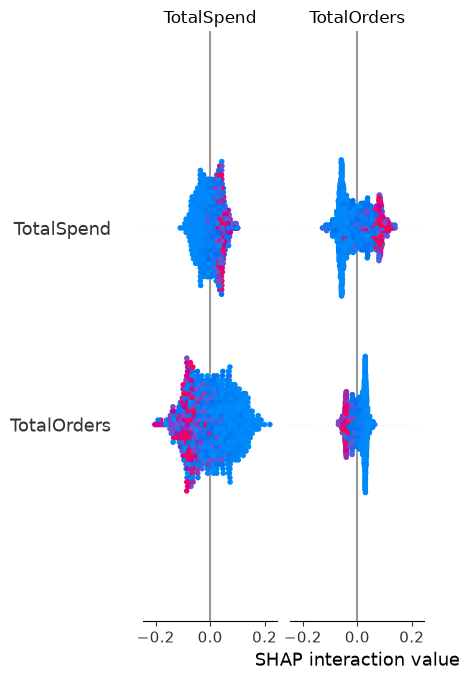

✅ SHAP Feature Importance plot saved successfully!


In [55]:
    import matplotlib.pyplot as plt

    # SHAP Feature Importance (Bar)
    shap.summary_plot(
        shap_values,
        X_test,
        plot_type="bar",
        show=False
    )

    plt.savefig(
        "../reports/shap_feature_importance.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("✅ SHAP Feature Importance plot saved successfully!")

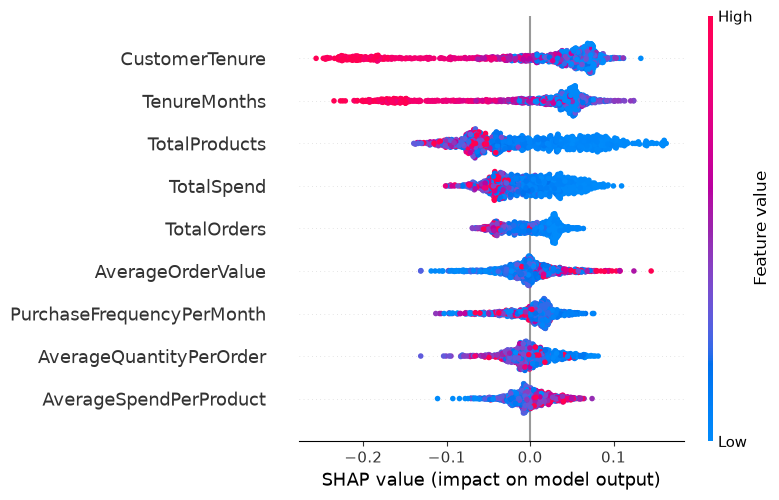

✅ Correct SHAP Beeswarm plot saved successfully!


In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values_class1,
    X_test,
    show=False
)

plt.savefig(
    "../reports/shap_summary_beeswarm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Correct SHAP Beeswarm plot saved successfully!")

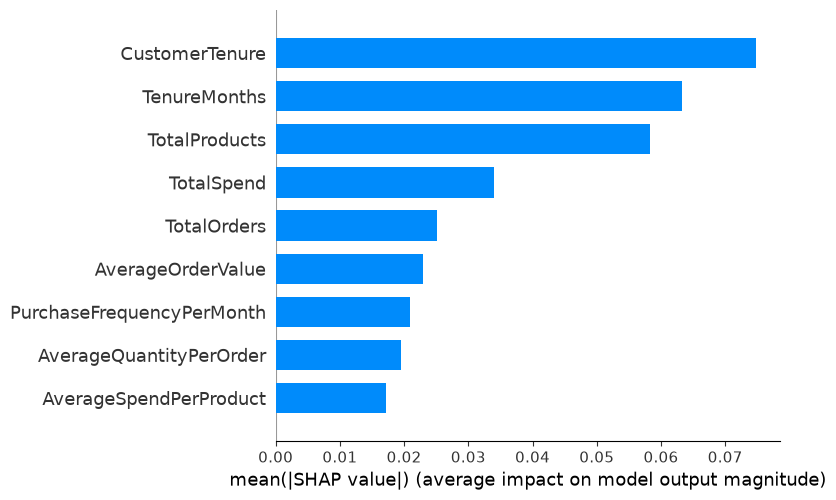

✅ SHAP Feature Importance Bar chart saved successfully!


In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

shap.summary_plot(
    shap_values_class1,
    X_test,
    plot_type="bar",
    show=False
)

plt.savefig(
    "../reports/shap_feature_importance_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ SHAP Feature Importance Bar chart saved successfully!")

<Figure size 800x600 with 0 Axes>

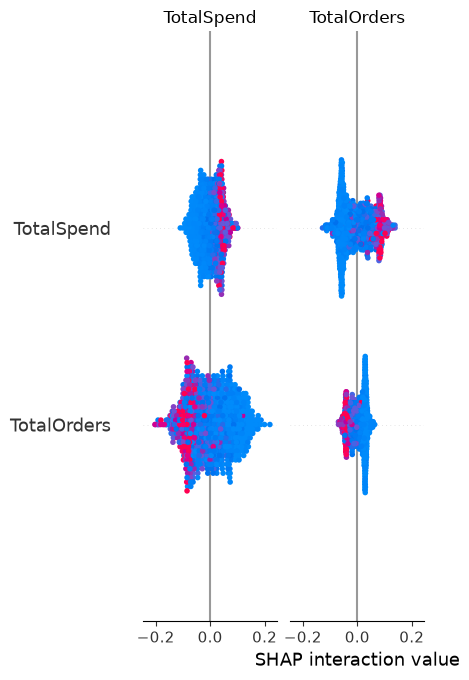

✅ SHAP Bar plot saved!


In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.savefig(
    "../reports/shap_feature_importance_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ SHAP Bar plot saved!")

In [52]:
type(shap_values)

numpy.ndarray

In [53]:
import numpy as np
print(np.array(shap_values).shape)

(1189, 9, 2)


In [1]:
print("Kernel OK")

Kernel OK


In [2]:
import shap
print(shap.__version__)

ImportError: DLL load failed while importing _dispatcher: An Application Control policy has blocked this file.

In [3]:
import sys
print(sys.executable)

c:\Users\ADMIN\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [1]:
import shap
print(shap.__version__)

c:\Users\ADMIN\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0.52.0
